# Mroz Dataset: Variable Dictionary

This dataset is used to study labor force participation and wages for women.

## Columns

- `lfp`: labor force participation indicator. `True`/`1` means the woman is in the labor force; `False`/`0` means she is not participating.
- `k5`: number of children under age 5 in the household. This captures childcare burden.
- `k618`: number of children age 6 to 18 in the household. This reflects older-child caregiving responsibilities.
- `age`: age of the woman in years. This helps capture life-cycle and experience effects.
- `wc`: wife/participant college indicator. `1` means college education, `0` otherwise.
- `hc`: husband college indicator. `1` means the husband has college education, `0` otherwise.
- `lwg`: log wage. This is the natural log of wages and is often used in labor economics because it handles skewed wage data better than raw wages.
- `inc`: household income. This is an income variable used to examine economic conditions and labor supply decisions.

## Why these variables matter
These variables help us study how family responsibilities, age, education, and income affect whether a woman works and how much she earns.

## Example question this dataset can answer
- Does having young children reduce labor force participation?
- Does college education increase wages?
- Is household income associated with labor supply decisions?

## What we are doing in this notebook
We will explore the relationships between income, wages, education, and family structure before fitting simple regression models.

In [1]:
# Setup and imports
# This cell loads the libraries we need to work with data tables, random/numeric operations,
# regression formulas, and plotting.
# Why: each library gives us a different tool: pandas for tables, numpy for math, statsmodels for modeling,
# seaborn for plotting, and causaldata for the example dataset.
# Useful for: preparing data, fitting regression models, and drawing graphs in a reproducible workflow.
# Alternative: we could use base Python and matplotlib instead of seaborn, but seaborn is faster for statistical plots.

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import seaborn as sns
import seaborn.objects as so
from causaldata import Mroz

In [2]:
# Load the dataset
# This cell reads the Mroz dataset, which is a classic labor economics dataset used for studying wages and work participation.
# Why: we need a real dataset to explore relationships between income, education, labor force participation, and wages.
# Useful for: learning how to inspect data before modeling and spotting patterns in a real-world sample.
# Alternative: we could use a CSV file from a local folder, but the causaldata package gives us a clean ready-to-use dataset.

# Read the Mroz dataset
dt = Mroz.load_pandas().data
dt.head()

,Unnamed: 0,lfp,k5,k618,age,wc,hc,lwg,inc
0,1,True,1,0,32,False,False,1.210165,10.910001
1,2,True,0,2,30,False,False,0.328504,19.500000
2,3,True,1,3,35,False,False,1.514128,12.039999
3,4,True,0,3,34,False,False,0.092115,6.800000
4,5,True,1,2,31,True,False,1.524280,20.100000


In [3]:
# Filter to working women only
# This cell keeps only rows where the labor-force participation flag is True.
# Why: the question is about earnings among working women, so we should remove observations that are not employed.
# Useful for: narrowing the sample to the group relevant to the analysis and making the relationship easier to interpret.
# Alternative: we could analyze all women in the dataset, but that would mix working and non-working respondents.

# Keep just working women
dt = dt[dt['lfp'] == True]

# create unlogged earnings variable
# We create an earnings variable by exponentiating log wages back to dollars.
# Why: many economic models work better in log terms, but it is helpful to also inspect actual earnings values.
# Useful for: comparing salary scales and creating interpretable plots.
# Alternative: we could keep only log wages (`lwg`) and skip the unlogged version, but raw earnings are easier to explain.
dt = dt.assign(earn = lambda x: np.exp(x['lwg']))
dt.head()

,Unnamed: 0,lfp,k5,k618,age,wc,hc,lwg,inc,earn
0,1,True,1,0,32,False,False,1.210165,10.910001,3.354037
1,2,True,0,2,30,False,False,0.328504,19.500000,1.388889
2,3,True,1,3,35,False,False,1.514128,12.039999,4.545455
3,4,True,0,3,34,False,False,0.092115,6.800000,1.096491
4,5,True,1,2,31,True,False,1.524280,20.100000,4.591837


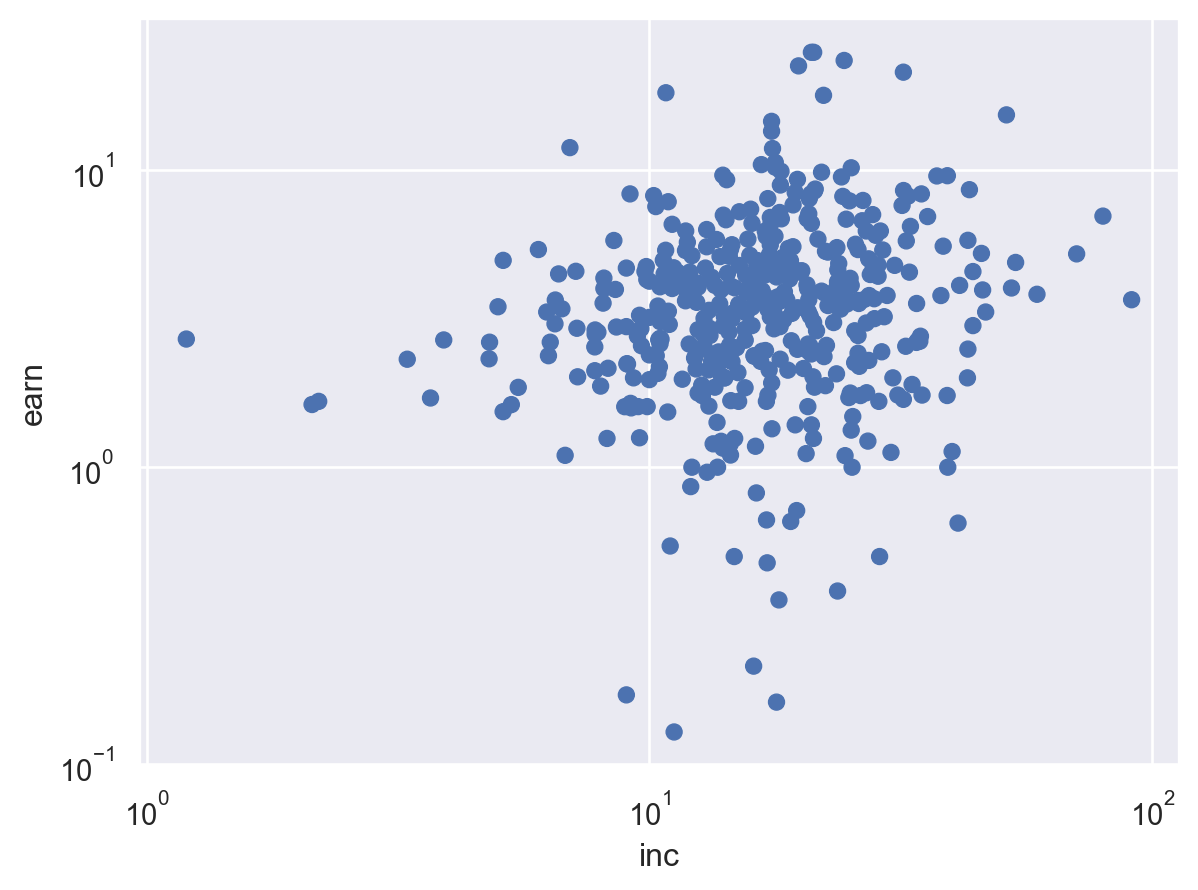

In [4]:
# Scatter plot of earnings vs. income with a regression line
# This cell draws a scatter plot where income is on the x-axis and earnings is on the y-axis.
# Why: visualizing the relationship helps us see whether earnings rise with income, whether the pattern is linear,
# and whether a log scale makes the pattern easier to interpret.
# Useful for: exploratory data analysis and for spotting outliers, curvature, or nonlinear patterns before modeling.
# Alternative: we could plot with a plain matplotlib scatter plot, but seaborn.objects allows a clean, concise statistical visualization.

so.Plot(dt, x='inc', y='earn') \
    .add(so.Dot()) \
        .scale(x = 'log', y = 'log') 

In [5]:
# Conditional mean by college attendance
# This cell calculates the average earnings for each value of the college variable (`wc`).
# Why: we want to compare earnings between groups, such as college graduates vs. non-graduates.
# Useful for: summarizing differences between categories and understanding whether the relationship varies by group.
# Alternative: a boxplot or bar chart could show the same idea visually, but this gives the actual average values directly.

# wc is the college variable
dt.groupby('wc').agg({'earn': 'mean'})

,earn
wc,
False,3.583539
True,5.349448


In [6]:
# Conditional mean by income bins
# This cell groups income into 10 bins using `pd.cut` and computes the mean earnings within each bin.
# Why: this reduces noise and helps show the average relationship between income and earnings more smoothly.
# Useful for: turning a continuous variable into a summarized view and spotting nonlinearity in a simple way.
# Alternative: a scatter plot can show the full relationship, while binning is a simpler summary when you want averages by ranges.

# Use the cut to get 10 bins
dt = dt.assign(inc_bin = lambda x: pd.cut(x['inc'], bins=10))
dt.groupby('inc_bin', observed=False).agg({'earn': 'mean'})

,earn
inc_bin,
"(-0.12, 9.074]",3.091594
"(9.074, 18.177]",3.826430
"(18.177, 27.28]",4.954454
"(27.28, 36.383]",4.563332
"(36.383, 45.485]",4.241790
"(45.485, 54.588]",6.139739
"(54.588, 63.691]",3.825000
"(63.691, 72.794]",5.232558
"(72.794, 81.897]",7.015306


/Users/gaurav/miniconda3/envs/stocks3/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='linc', ylabel='lwg'>

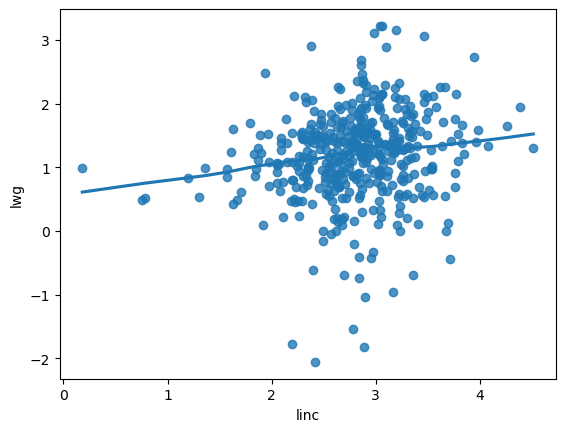

In [7]:
# Plot a smoothing curve and a linear regression line
# This cell creates a regression plot on log-income and log-wage data with a LOWESS smoother.
# Why: it helps us compare a flexible non-linear trend against a simple straight-line model.
# Useful for: deciding whether the relationship is approximately linear or whether a curve is needed.
# Alternative: a simple scatter plot without a smooth line is possible, but the lowess line helps reveal structure in the data.

# Do log before this axes
dt = dt.assign(linc = lambda x: np.log(x['inc']))
sns.regplot(data=dt, x='linc', y='lwg', lowess=True, ci=None)

In [8]:
# Fit a simple linear regression model
# This cell estimates a model where log wages are explained by log income.
# Why: we want to quantify the relationship in a simple, interpretable way before adding other variables.
# Useful for: measuring the baseline association and seeing how much of the variation in wages is explained by income alone.
# Alternative: we could skip regression and only inspect plots, but regression gives numbers and statistical summaries.

m1 = smf.ols('lwg ~ linc', data=dt).fit()
print(m1.summary())

                            OLS Regression Results                            
Dep. Variable:                    lwg   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     11.65
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           0.000703
Time:                        22:10:18   Log-Likelihood:                -461.34
No. Observations:                 427   AIC:                             926.7
Df Residuals:                     425   BIC:                             934.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5690      0.185      3.079      0.0

In [9]:
# Fit a richer regression model with controls
# This cell adds college status (`wc`) and number of young children (`k5`) to the model.
# Why: we want to know whether the income-wage relationship still holds after accounting for education and family structure.
# Useful for: controlling for confounders and improving the interpretation of the coefficient on income.
# Alternative: we could run a model with only income, but adding controls helps reduce omitted-variable bias.

# K5 is the number of kids under 5 in the house
m2 = smf.ols(formula='lwg ~ linc + wc + k5', data=dt).fit()
print(m2.summary())

                            OLS Regression Results                            
Dep. Variable:                    lwg   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.064
Method:                 Least Squares   F-statistic:                     10.67
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           8.92e-07
Time:                        22:10:18   Log-Likelihood:                -451.54
No. Observations:                 427   AIC:                             911.1
Df Residuals:                     423   BIC:                             927.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.7065      0.184      3.833      0.0

# Comparing Model 1 (`m1`) and Model 2 (`m2`): Which is Better?

**Model 2 (`lwg ~ linc + wc + k5`) is the better model.** Here is why, with every parameter in the output explained.

## 1. Model Fit Statistics (top block of the output)

| Parameter | m1 (`lwg ~ linc`) | m2 (`lwg ~ linc + wc + k5`) | What it means |
|---|---|---|---|
| **Dep. Variable** | `lwg` | `lwg` | The outcome we are predicting: log of wages. Same in both models, so they are comparable. |
| **R-squared** | 0.027 | 0.070 | Share of variation in log wages explained by the model. m1 explains only 2.7%; m2 explains 7.0% — almost 3× more. **Higher is better → m2 wins.** |
| **Adj. R-squared** | 0.024 | 0.064 | R² adjusted for the number of predictors (penalizes adding useless variables). m2 is still much higher even after the penalty, so the extra variables are pulling their weight. **Higher is better → m2 wins.** |
| **F-statistic** | 11.65 | 10.67 | Tests whether *all* slope coefficients together are different from zero (overall model significance). |
| **Prob (F-statistic)** | 0.000703 | 8.92e-07 | p-value for the F-test. Both are far below 0.05, so both models are statistically significant overall — but m2's is much smaller, meaning stronger overall evidence. |
| **Log-Likelihood** | -461.34 | -451.54 | How likely the data is given the model. Less negative = better fit. **m2 wins.** |
| **AIC** | 926.7 | 911.1 | Akaike Information Criterion — balances fit against model complexity. **Lower is better → m2 wins by ~15 points** (a difference > 10 is considered strong evidence). |
| **BIC** | 934.8 | 927.3 | Bayesian Information Criterion — like AIC but penalizes extra parameters more heavily. **Lower is better → m2 still wins**, so the added variables are worth their cost. |
| **No. Observations** | 427 | 427 | Same sample (working women only), so the comparison is fair. |
| **Df Residuals / Df Model** | 425 / 1 | 423 / 3 | Degrees of freedom: m2 uses 2 more for its extra predictors (`wc`, `k5`). |
| **Covariance Type** | nonrobust | nonrobust | Standard errors assume classical OLS assumptions (homoskedasticity). Same for both. |

## 2. Coefficient Table (middle block)

| Term | coef | std err | t | P>\|t\| | [0.025, 0.975] |
|---|---|---|---|---|---|
| **m1: Intercept** | 0.5690 | 0.185 | 3.079 | 0.002 | [0.206, 0.932] |
| **m1: linc** | 0.2207 | 0.065 | 3.413 | 0.001 | [0.094, 0.348] |
| **m2: Intercept** | 0.7065 | 0.184 | 3.833 | 0.000 | [0.344, 1.069] |
| **m2: wc[T.True]** | 0.3353 | 0.075 | 4.450 | 0.000 | [0.187, 0.483] |
| **m2: linc** | 0.1351 | 0.066 | 2.041 | 0.042 | [0.005, 0.265] |
| **m2: k5** | -0.0675 | 0.087 | -0.775 | 0.439 | [-0.239, 0.104] |

What each column means:

- **coef** — the estimated effect on log wages.
  - `linc` in m1 = 0.2207: a 1% increase in household income is associated with ≈ 0.22% higher wages (log-log = elasticity).
  - `linc` in m2 drops to 0.1351 once education and children are controlled for — meaning part of m1's income effect was actually picking up education effects (omitted-variable bias). This is a key reason m2 is more trustworthy.
  - `wc[T.True]` = 0.3353: college-educated women earn about $e^{0.3353} - 1 \approx 39.8\%$ more than non-college women, holding income and children constant.
  - `k5` = -0.0675: each additional child under 5 is associated with ≈ 6.5% lower wages, but this is **not statistically significant**.
- **std err** — standard error: the uncertainty of the coefficient estimate. Smaller = more precise.
- **t** — t-statistic = coef / std err. Tests whether that single coefficient is different from zero. |t| > ~2 usually means significant.
- **P>|t|** — p-value for that t-test. Below 0.05 = statistically significant. In m2, `wc` (0.000) and `linc` (0.042) are significant; `k5` (0.439) is not — we cannot conclude young children affect wages here.
- **[0.025, 0.975]** — 95% confidence interval for the coefficient. If it includes 0 (like `k5`: [-0.239, 0.104]), the effect is not statistically significant.

## 3. Residual Diagnostics (bottom block)

| Parameter | m1 | m2 | What it means |
|---|---|---|---|
| **Omnibus / Prob(Omnibus)** | 65.243 / 0.000 | 82.950 / 0.000 | Tests whether residuals are normally distributed. p ≈ 0 in both → residuals are **not** normal in either model. |
| **Skew** | -0.761 | -0.889 | Asymmetry of residuals. 0 = symmetric. Both are left-skewed; m2 slightly more so. |
| **Kurtosis** | 5.626 | 6.332 | Tail heaviness. 3 = normal. Both have fat tails (outliers present). |
| **Jarque-Bera (JB) / Prob(JB)** | 163.9 / 2.6e-36 | 253.7 / 8.0e-56 | Combines skew and kurtosis into a normality test. Both reject normality strongly. |
| **Durbin-Watson** | 1.947 | 2.001 | Tests autocorrelation in residuals. Values near 2 = no autocorrelation. **m2 is essentially perfect (2.001)**; both are fine. |
| **Cond. No.** | 17.1 | 17.6 | Condition number — checks multicollinearity. Both are well below 30, so **no multicollinearity problem** even with the added variables in m2. |

## Conclusion

**Model 2 is better** because:

1. **Higher explanatory power** — Adj. R² rises from 0.024 to 0.064 (nearly 3×), and the penalty for extra variables doesn't erase the gain.
2. **Better information criteria** — AIC drops by ~15.6 and BIC by ~7.5; both favor m2, meaning the added predictors improve the model more than they cost in complexity.
3. **Less biased estimates** — the `linc` coefficient shrinks from 0.221 to 0.135 once `wc` is included, showing m1 overstated the income effect by omitting education. m2 gives a more honest, controlled estimate.
4. **No diagnostic red flags introduced** — Durbin-Watson improves to ~2.0 and the condition number stays low (17.6), so adding variables caused no autocorrelation or multicollinearity problems.

**Caveats:** both models still have low R² (wages depend on many unobserved factors), non-normal residuals (consider robust standard errors), and `k5` is insignificant in m2 — it could be dropped without hurting the model.